# AIML505 Course Project — Group J 
**Soil Moisture Forecasting and Smart Irrigation Decision Support**

**Track B: Graph based models**

**Team:** Jobayer Faisal Fahim (2026-2-74-014) · Md. Rafiqul Islam (2026-2-74-025) 

**Dataset:** [Bhopal AgriTech Hybrid IoT Dataset for Predictive Irrigation (Kaggle)](https://www.kaggle.com/datasets/akshaymp08/bhopal-agritech-dataset-for-predictive-irrigation)


# T-GCN — Temporal Graph Convolutional Network


## Setup — Load data, build graph, build windows (same as main notebook)

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = "/kaggle/input/datasets/akshaymp08/bhopal-agritech-dataset-for-predictive-irrigation/Bhopal-AgriTech Hybrid IoT Dataset for Predictive Irrigation.csv"
df = pd.read_csv(DATA_PATH)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

target_col = "soil_moisture_next_1m"
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()
print(f"Train: {len(train_df):,} rows | Test: {len(test_df):,} rows")

Train: 33,352 rows | Test: 8,339 rows


In [2]:
def eval_metrics(y_true, y_pred):
    return (
        np.sqrt(mean_squared_error(y_true, y_pred)),
        mean_absolute_error(y_true, y_pred),
        r2_score(y_true, y_pred),
    )

def mean_absolute_percentage_error_safe(y_true, y_pred, epsilon=1e-6):
    """Safe MAPE — avoids divide-by-near-zero blowups."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true), epsilon)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def count_params(model):
    return int(sum(p.numel() for p in model.parameters() if p.requires_grad))
graph_nodes = ["Soil_Moisture", "Temperature", "Humidity", "irrigation_status", "Hour_sin", "Hour_cos"]
n_nodes = len(graph_nodes)


corr_graph = df[graph_nodes].corr().values
np.fill_diagonal(corr_graph, 0)

edge_index_list, edge_weight_list = [], []
for i in range(n_nodes):
    for j in range(n_nodes):
        if i != j:
            edge_index_list.append([i, j])
            edge_weight_list.append(abs(corr_graph[i, j]))

edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
print(f"edge_index shape: {edge_index.shape}")

edge_index shape: torch.Size([2, 30])


In [3]:
WINDOW = 60

node_scalers = {}
train_scaled_g, test_scaled_g = {}, {}
for col in graph_nodes:
    sc = MinMaxScaler()
    train_scaled_g[col] = sc.fit_transform(train_df[[col]]).flatten()
    test_scaled_g[col] = sc.transform(test_df[[col]]).flatten()
    node_scalers[col] = sc

target_scaler_g = MinMaxScaler()
train_target_scaled_g = target_scaler_g.fit_transform(train_df[[target_col]]).flatten()
test_target_scaled_g = target_scaler_g.transform(test_df[[target_col]]).flatten()

def build_windows(scaled_dict, target_scaled, window):
    n = len(next(iter(scaled_dict.values())))
    X, y = [], []
    for t in range(n - window):
        snapshot = np.stack([scaled_dict[col][t:t + window] for col in graph_nodes])
        X.append(snapshot)
        y.append(target_scaled[t + window])
    return np.array(X), np.array(y)

X_train_g, y_train_g = build_windows(train_scaled_g, train_target_scaled_g, WINDOW)
X_test_g, y_test_g = build_windows(test_scaled_g, test_target_scaled_g, WINDOW)

y_true_g = target_scaler_g.inverse_transform(y_test_g.reshape(-1, 1)).flatten()
print(f"X_train_g: {X_train_g.shape}  X_test_g: {X_test_g.shape}")

X_train_g: (33292, 6, 60)  X_test_g: (8279, 6, 60)


In [4]:
import torch
TORCH_VERSION = torch.__version__.split("+")[0]
CUDA_VERSION = "cu" + torch.version.cuda.replace(".", "") if torch.cuda.is_available() else "cpu"
wheel_url = f"https://data.pyg.org/whl/torch-{TORCH_VERSION}+{CUDA_VERSION}.html"
print(f"Using wheel index: {wheel_url}")
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv -f {wheel_url} -q
!pip install torch_geometric torch_geometric_temporal -q

Using wheel index: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 11.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.2/828.2 kB 42.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.9/306.9 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 6.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mne 1.12.1 requires decorator>=5.1, but you have decorator 4.4.2 which is incompatible.


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X_train_t = torch.tensor(X_train_g, dtype=torch.float32)
y_train_t = torch.tensor(y_train_g, dtype=torch.float32).unsqueeze(-1)
X_test_t = torch.tensor(X_test_g, dtype=torch.float32)

edge_index_dev = edge_index.to(device)
edge_weight_dev = edge_weight.to(device)

batch_size = 128
n_batches = len(X_train_t) // batch_size
loss_fn = nn.MSELoss()

Using device: cpu


In [6]:
train_seq = np.stack([train_scaled_g[col] for col in graph_nodes], axis=1)
test_seq = np.stack([test_scaled_g[col] for col in graph_nodes], axis=1)
CHUNK = 60
n_chunks = (len(train_seq) - 1) // CHUNK
print(f"n_chunks per epoch: {n_chunks}")

n_chunks per epoch: 555


## T-GCN Model

In [7]:
from torch_geometric_temporal.nn.recurrent import TGCN

class TGCNForecaster(nn.Module):
    def __init__(self, in_channels=1, hidden_channels=32):
        super().__init__()
        self.tgcn = TGCN(in_channels, hidden_channels)
        self.readout = nn.Linear(hidden_channels * n_nodes, 1)

    def forward(self, x, edge_index, edge_weight, h=None):
        h = self.tgcn(x, edge_index, edge_weight, h)
        return self.readout(h.flatten()), h

print("T-GCN model class defined.")

T-GCN model class defined.


## Extended Training — watch the loss curve


In [8]:
N_EPOCHS = 50

model = TGCNForecaster().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
train_losses = []


train_start = time.time()
model.train()
for epoch in range(N_EPOCHS):
    h = None
    total_loss = 0.0
    for c in range(n_chunks):
        optimizer.zero_grad()
        chunk_loss = 0.0
        h_local = h.detach() if h is not None else None
        for t in range(c*CHUNK, (c+1)*CHUNK):
            x_t = torch.tensor(train_seq[t], dtype=torch.float32).unsqueeze(-1).to(device)
            y_t = torch.tensor([train_target_scaled_g[t]], dtype=torch.float32).to(device)
            pred, h_local = model(x_t, edge_index_dev, edge_weight_dev, h_local)
            chunk_loss = chunk_loss + loss_fn(pred, y_t)
        chunk_loss = chunk_loss / CHUNK
        chunk_loss.backward()
        optimizer.step()
        h = h_local.detach()
        total_loss += chunk_loss.item()
    avg_loss = total_loss / n_chunks
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{N_EPOCHS}: avg chunk loss={avg_loss:.6f}")
    train_time = time.time() - train_start

Epoch 1/50: avg chunk loss=0.022511
Epoch 2/50: avg chunk loss=0.002373
Epoch 3/50: avg chunk loss=0.004000
Epoch 4/50: avg chunk loss=0.000510
Epoch 5/50: avg chunk loss=0.005173
Epoch 6/50: avg chunk loss=0.000391
Epoch 7/50: avg chunk loss=0.001824
Epoch 8/50: avg chunk loss=0.001060
Epoch 9/50: avg chunk loss=0.003334
Epoch 10/50: avg chunk loss=0.000585
Epoch 11/50: avg chunk loss=0.000808
Epoch 12/50: avg chunk loss=0.002779
Epoch 13/50: avg chunk loss=0.000517
Epoch 14/50: avg chunk loss=0.000758
Epoch 15/50: avg chunk loss=0.000686
Epoch 16/50: avg chunk loss=0.002741
Epoch 17/50: avg chunk loss=0.000346
Epoch 18/50: avg chunk loss=0.000439
Epoch 19/50: avg chunk loss=0.002216
Epoch 20/50: avg chunk loss=0.000472
Epoch 21/50: avg chunk loss=0.000546
Epoch 22/50: avg chunk loss=0.000579
Epoch 23/50: avg chunk loss=0.000567
Epoch 24/50: avg chunk loss=0.002461
Epoch 25/50: avg chunk loss=0.000377
Epoch 26/50: avg chunk loss=0.000371
Epoch 27/50: avg chunk loss=0.000472
Epoch 28/5

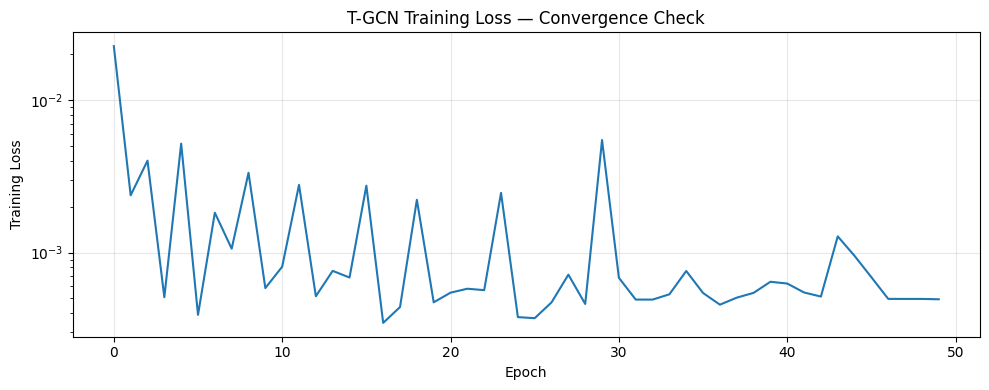


First 5 epochs avg loss: 0.006913
Last 5 epochs avg loss:  0.000535
Loss still decreasing in final 5 epochs: True


In [9]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("T-GCN Training Loss — Convergence Check")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFirst 5 epochs avg loss: {np.mean(train_losses[:5]):.6f}")
print(f"Last 5 epochs avg loss:  {np.mean(train_losses[-5:]):.6f}")
print(f"Loss still decreasing in final 5 epochs: {train_losses[-1] < train_losses[-5]}")

## Evaluation

In [10]:
model.eval()
preds = []
h = None
with torch.no_grad():
    for t in range(len(test_seq)):
        x_t = torch.tensor(test_seq[t], dtype=torch.float32).unsqueeze(-1).to(device)
        pred, h = model(x_t, edge_index_dev, edge_weight_dev, h)
        preds.append(pred.cpu().item())

pred_scaled = np.array(preds[:-1])
y_true_scaled = test_target_scaled_g[1:]
pred = target_scaler_g.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
y_true = target_scaler_g.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()

rmse, mae, r2 = eval_metrics(y_true, pred)
mape = mean_absolute_percentage_error_safe(y_true, pred)
n_params = count_params(model)

print(f"T-GCN ({N_EPOCHS} epochs) — RMSE: {rmse:.4f}  MAE: {mae:.4f}  MAPE: {mape:.2f}%  R2: {r2:.4f}  Train Time: {train_time:.1f}s, num_params: {n_params:,} params")
print()
print("For reference:")
print(f" Original run (5 epochs):  RMSE: 4.911158  MAE: 3.932532  R2: 0.780958  MAPE: 13.893792%   Train Time: 798.828469s, num_params: 6625.0 params")

T-GCN (50 epochs) — RMSE: 1.5955  MAE: 1.0094  MAPE: 3.32%  R2: 0.9769  Train Time: 3930.6s, num_params: 6,625 params

For reference:
 Original run (5 epochs):  RMSE: 4.911158  MAE: 3.932532  R2: 0.780958  MAPE: 13.893792%   Train Time: 798.828469s, num_params: 6625.0 params


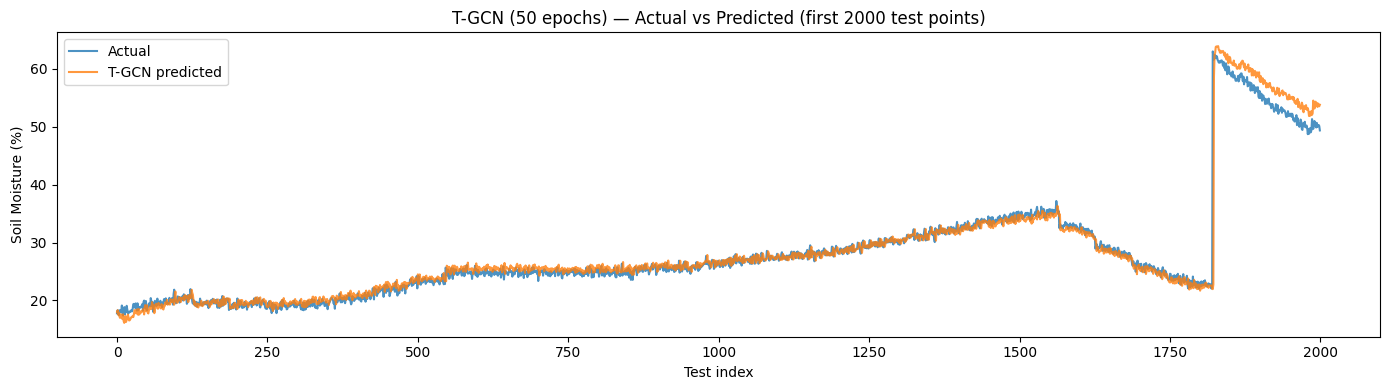

In [11]:
plt.figure(figsize=(14, 4))
plt.plot(y_true[:2000], label="Actual", alpha=0.8)
plt.plot(pred[:2000], label="T-GCN predicted", alpha=0.8)
plt.title(f"T-GCN ({N_EPOCHS} epochs) — Actual vs Predicted (first 2000 test points)")
plt.xlabel("Test index")
plt.ylabel("Soil Moisture (%)")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
result_row = pd.DataFrame([{
    "model": "T-GCN",
    "epochs": N_EPOCHS,
    "rmse": rmse,
    "mae": mae,
    "mape": mape,
    "r2": r2,
    "training_time_s": train_time,
    "num_params": n_params,
}])
result_row.to_csv("T-GCN_extended_result.csv", index=False)
result_row

,model,epochs,rmse,mae,mape,r2,training_time_s,num_params
0,T-GCN,50,1.595516,1.009386,3.320996,0.976881,3930.602814,6625


In [13]:
import glob
import pandas as pd

files = glob.glob("T-GCN_extended_result.csv")
combined = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
combined = combined.sort_values("rmse").reset_index(drop=True)
combined

,model,epochs,rmse,mae,mape,r2,training_time_s,num_params
0,T-GCN,50,1.595516,1.009386,3.320996,0.976881,3930.602814,6625
